In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('spam.csv', encoding='latin1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

## Data Cleaning

In [7]:
df[df['Unnamed: 2'].isnull() == False] ## Just checking 

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
95,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
281,ham,\Wen u miss someone,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve.."""
444,ham,\HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAR...,HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE ...,NaN,NaN
671,spam,SMS. ac sun0819 posts HELLO:\You seem cool,"wanted to say hi. HI!!!\"" Stop? Send STOP to ...",NaN,NaN
710,ham,Height of Confidence: All the Aeronautics prof...,"this wont even start........ Datz confidence..""",NaN,NaN
899,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
1038,ham,"Edison has rightly said, \A fool can ask more ...",GN,GE,"GNT:-)"""
1127,ham,"Height of \Oh shit....!!\"" situation: A guy th...",".;-):-D""",NaN,NaN
1266,ham,\Hey sorry I didntgive ya a a bellearlier hunny,just been in bedbut mite go 2 thepub l8tr if u...,NaN,NaN
1384,ham,"Storming msg: Wen u lift d phne, u say \HELLO\...","bt not his girlfrnd... G o o d n i g h t . . .@""",NaN,NaN


In [8]:
df.drop(columns = ['Unnamed: 3','Unnamed: 2','Unnamed: 4'],inplace=True)

In [9]:
df.shape

(5572, 2)

In [10]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
df.rename(columns={'v1':'Spam_or_Not','v2':'The Message'},inplace=True)

In [12]:
df

,Spam_or_Not,The Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [13]:
from sklearn.preprocessing import LabelEncoder

In [14]:
le = LabelEncoder()

In [15]:
 k = le.fit_transform(df['Spam_or_Not'])

In [16]:
df['Target'] = k

In [17]:
df.head()  # 0 means Not spam and 1 means Spam

,Spam_or_Not,The Message,Target
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [18]:
df.drop(columns=['Spam_or_Not'])

,The Message,Target
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...
5567,This is the 2nd time we have tried 2 contact u...,1
5568,Will Ì_ b going to esplanade fr home?,0
5569,"Pity, * was in mood for that. So...any other s...",0
5570,The guy did some bitching but I acted like i'd...,0


In [19]:
df = df[['Target','The Message']]

In [20]:
df

,Target,The Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [21]:
df.duplicated().sum()

np.int64(403)

In [22]:
df.drop_duplicates(keep='first',inplace=True)

C:\Users\Harshgupta\AppData\Local\Temp\ipykernel_15392\313269892.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first',inplace=True)


In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.head()

,Target,The Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## EDA 

In [25]:
df

,Target,The Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


#### Data is Imbalance

Text(0.5, 1.0, 'Percentage of Spam and Ham in data')

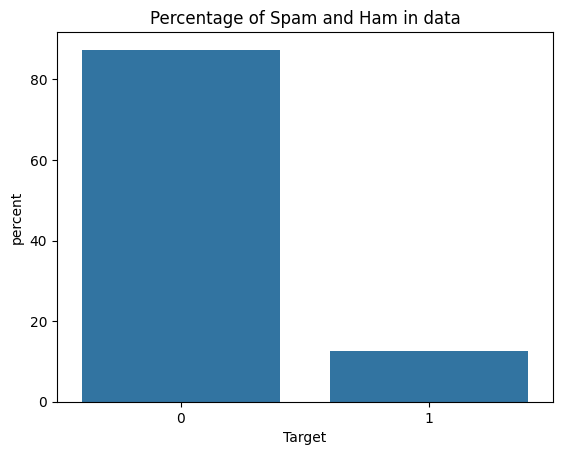

In [26]:
sns.countplot(x = df['Target'],stat='percent')
plt.title('Percentage of Spam and Ham in data')

In [27]:
pip install nltk 

Note: you may need to restart the kernel to use updated packages.


In [28]:
import nltk

In [29]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Harshgupta\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [30]:
df['Number of Characters'] = df['The Message'].apply(len)

C:\Users\Harshgupta\AppData\Local\Temp\ipykernel_15392\2191811808.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Number of Characters'] = df['The Message'].apply(len)


In [31]:
df['Count of Words'] = df['The Message'].apply(lambda x:len(nltk.word_tokenize(x)))

C:\Users\Harshgupta\AppData\Local\Temp\ipykernel_15392\1203275940.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Count of Words'] = df['The Message'].apply(lambda x:len(nltk.word_tokenize(x)))


In [32]:
df

,Target,The Message,Number of Characters,Count of Words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15
...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35
5568,0,Will Ì_ b going to esplanade fr home?,37,9
5569,0,"Pity, * was in mood for that. So...any other s...",57,15
5570,0,The guy did some bitching but I acted like i'd...,125,27


In [33]:
df['Count of Sentence'] = df['The Message'].apply(lambda x:len(nltk.sent_tokenize(x)))

C:\Users\Harshgupta\AppData\Local\Temp\ipykernel_15392\1652612812.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Count of Sentence'] = df['The Message'].apply(lambda x:len(nltk.sent_tokenize(x)))


In [34]:
df[['Number of Characters','Count of Words','Count of Sentence']].describe()

,Number of Characters,Count of Words,Count of Sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.460437,1.965564
std,58.236293,13.334441,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


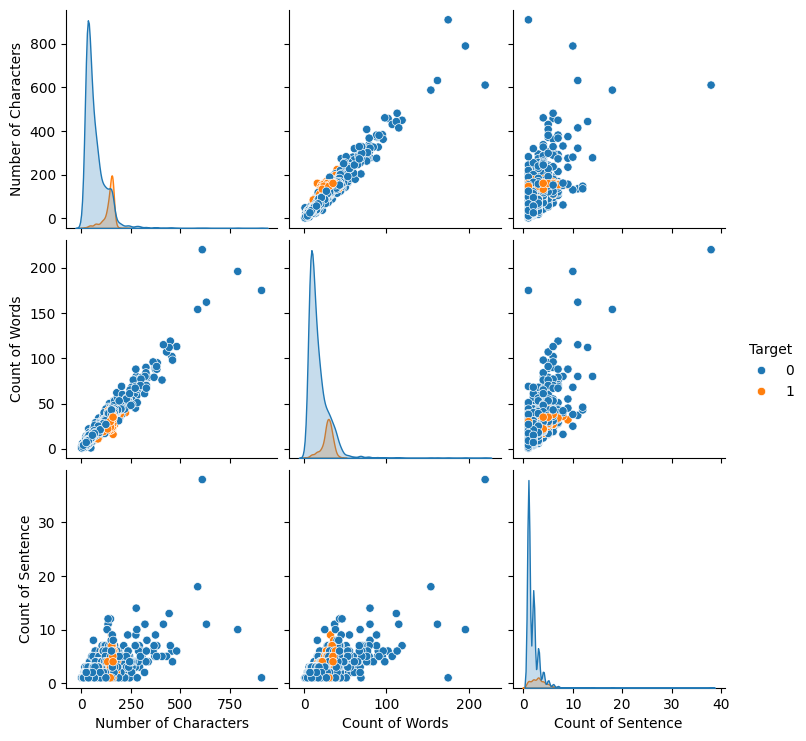

In [35]:
sns.pairplot(
    df[['Number of Characters', 'Count of Words', 'Count of Sentence', 'Target']],
    hue='Target'
)

In [36]:
# Ham
df[df['Target']==0][['Number of Characters', 'Count of Words', 'Count of Sentence']].describe()

,Number of Characters,Count of Words,Count of Sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.128432,1.820195
std,56.358207,13.504730,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [37]:
# Spam
df[df['Target']==1][['Number of Characters', 'Count of Words', 'Count of Sentence']].describe()

,Number of Characters,Count of Words,Count of Sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.672282,2.970904
std,30.137753,7.010932,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [38]:
df.corr(numeric_only=True)

,Target,Number of Characters,Count of Words,Count of Sentence
Target,1.000000,0.384717,0.262720,0.263939
Number of Characters,0.384717,1.000000,0.965686,0.624139
Count of Words,0.262720,0.965686,1.000000,0.679767
Count of Sentence,0.263939,0.624139,0.679767,1.000000


<Axes: >

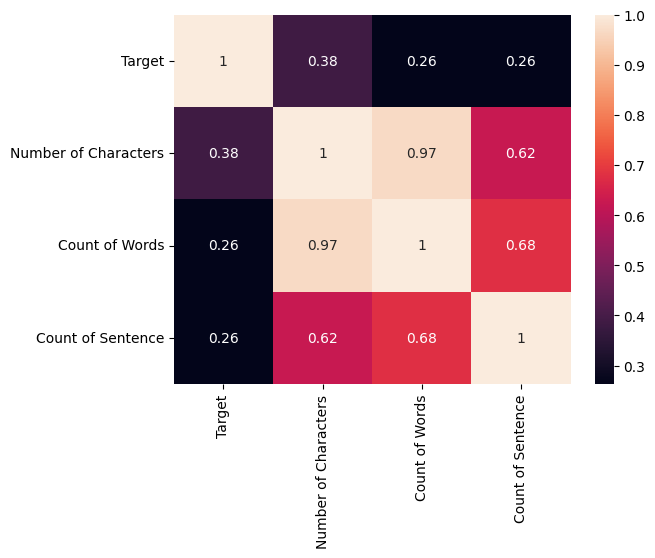

In [39]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

## Data Processing
- lower case
- Tokenization
- Removing special character
- Removing stop words and punctuation
- Stemming

In [40]:
from nltk.corpus import stopwords 
import string

In [41]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('Dancing')

'danc'

In [42]:
def transform_text(data):
    data = data.lower()
    data = nltk.word_tokenize(data)
    lst = []
    for i in data:
        if i.isalnum():
            lst.append(i)
    data = lst[:]
    lst.clear()
    for i in data:
        if i not in stopwords.words('english') and i not in string.punctuation:
            lst.append(i)

    data = lst[:]
    lst.clear()
    for i in data:
        lst.append(ps.stem(i))
        
    return " ".join(lst)

In [43]:
transform_text('Hello Harsh How are%%% you??')

'hello harsh'

In [44]:
transform_text('Heyi how you doing that a very great start !')

'heyi great start'

In [45]:
transform_text('I loved soo much Learning ML from Campusx ')

'love soo much learn ml campusx'

In [46]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [47]:
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [48]:
df['The Message'].sample()

2934    Yeah, we got one lined up for us
Name: The Message, dtype: object

In [49]:
df['Transformed Text'] = df['The Message'].apply(transform_text)

C:\Users\Harshgupta\AppData\Local\Temp\ipykernel_15392\371693635.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Transformed Text'] = df['The Message'].apply(transform_text)


In [50]:
df

,Target,The Message,Number of Characters,Count of Words,Count of Sentence,Transformed Text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4,2nd time tri 2 contact u pound prize 2 claim e...
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1,b go esplanad fr home
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2,piti mood suggest
5570,0,The guy did some bitching but I acted like i'd...,125,27,1,guy bitch act like interest buy someth els nex...


In [51]:
from wordcloud import WordCloud

In [52]:
wc = WordCloud(background_color='white',include_numbers=True, min_font_size=9,width=500,height=300)

In [53]:
spam_wc = wc.generate(df[df['Target']==1]['Transformed Text'].str.cat(sep=' '))

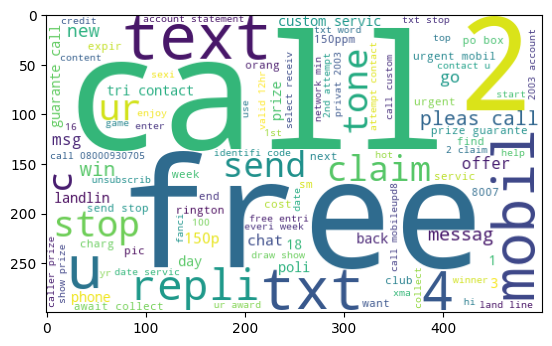

In [54]:
plt.imshow(spam_wc)

In [55]:
ham_wc = wc.generate(df[df['Target']==0]['Transformed Text'].str.cat(sep=' '))

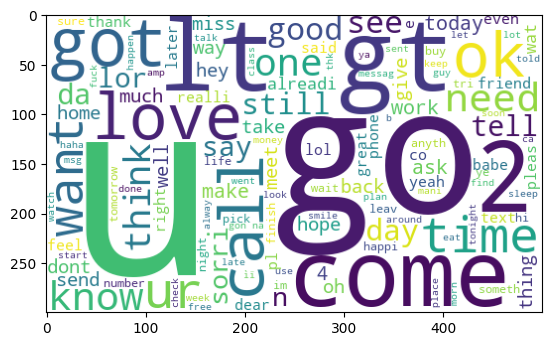

In [56]:
plt.imshow(ham_wc)

In [57]:
df

,Target,The Message,Number of Characters,Count of Words,Count of Sentence,Transformed Text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4,2nd time tri 2 contact u pound prize 2 claim e...
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1,b go esplanad fr home
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2,piti mood suggest
5570,0,The guy did some bitching but I acted like i'd...,125,27,1,guy bitch act like interest buy someth els nex...


In [58]:
spam_corpus = []
for msg in df[df['Target']==1]['Transformed Text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [59]:
len(spam_corpus)

9942

In [60]:
from collections import Counter
top_30_spam =pd.DataFrame(Counter(spam_corpus).most_common(30))

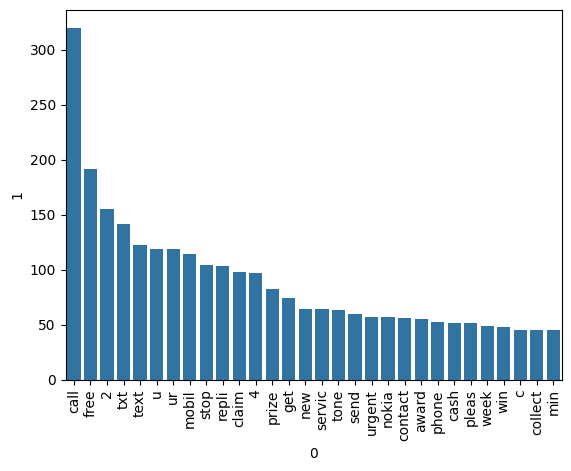

In [61]:
sns.barplot(x = top_30_spam[0],y = top_30_spam[1])
plt.xticks(rotation=90)
plt.show()

In [62]:
ham_corpus = []
for msg in df[df['Target']==0]['Transformed Text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [63]:
len(ham_corpus)

35423

In [64]:
top_30_ham =pd.DataFrame(Counter(ham_corpus).most_common(30))

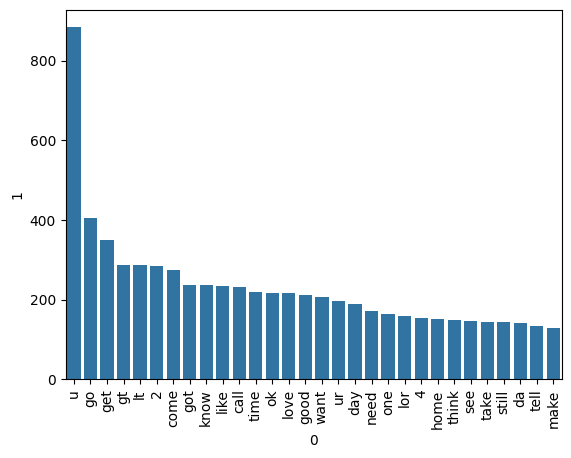

In [65]:
sns.barplot(x = top_30_ham[0],y = top_30_ham[1])
plt.xticks(rotation=90)
plt.show()

## Model Building

In [124]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer  # Text to Vectoer(Number) mai convert krne wali technique he

In [67]:
cv = CountVectorizer() # thik thak aya perfromance

In [125]:
tfid = TfidfVectorizer(max_features=3000) # better aya

In [126]:
X = tfid.fit_transform(df['Transformed Text']).toarray()

In [127]:
X.shape

(5169, 3000)

In [128]:
y = df['Target']

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix

In [129]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [74]:
from sklearn.naive_bayes import GaussianNB,BernoulliNB,MultinomialNB # Why Naive Bayes because Textual data pe best performance deta hai isliye uske sath start kiya

In [75]:
gnb = GaussianNB()
bnb = BernoulliNB()
mnb = MultinomialNB()

In [97]:
gnb.fit(X_train,y_train)
y_pred = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.8733075435203095
0.5159817351598174
[[790 106]
 [ 25 113]]


In [98]:
bnb.fit(X_train,y_train)
y_pred1 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(precision_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))

0.9835589941972921
0.991869918699187
[[895   1]
 [ 16 122]]


In [99]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(precision_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))

0.9709864603481625
1.0
[[896   0]
 [ 30 108]]


In [79]:
# Abhi tk ke liye ye apna TfidVector wala with MNB accha perform kr rhe hai

In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [81]:
lrc = LogisticRegression(solver='liblinear',penalty='l1')
svc1 = SVC(kernel='sigmoid',gamma=1.0)
svc2 = SVC(kernel='rbf',gamma=1.0)
mnb = MultinomialNB()
dtc1 = DecisionTreeClassifier(max_depth=5)
dtc2 = DecisionTreeClassifier(max_depth=8)
knc = KNeighborsClassifier()
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
ada = AdaBoostClassifier(n_estimators=50, random_state=2)
bgc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2) ## More Randomness that normal tree
gbc = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

In [82]:
clfs = {
    'SVC1' : svc1,
    'SVC2' : svc2,
    'KN' : knc, 
    'NB': mnb, 
    'DT1': dtc1, 
    'DT2': dtc2, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': ada, 
    'BgC': bgc, 
    'ETC': etc,
    'GBDT':gbc,
    'xgb':xgb
}

In [83]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    prec = precision_score(y_test,y_pred)
    acc = accuracy_score(y_test,y_pred)
    
    return prec,acc

In [100]:
train_classifier(svc1,X_train,y_train,X_test,y_test)

(0.9747899159663865, 0.9758220502901354)

In [101]:
train_classifier(svc2,X_train,y_train,X_test,y_test)

(0.9826086956521739, 0.9738878143133463)

In [102]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_precision,current_accuracy = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC1
Accuracy -  0.9758220502901354
Precision -  0.9747899159663865
For  SVC2
Accuracy -  0.9738878143133463
Precision -  0.9826086956521739
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.9709864603481625
Precision -  1.0
For  DT1
Accuracy -  0.9323017408123792
Precision -  0.8333333333333334
For  DT2
Accuracy -  0.9429400386847195
Precision -  0.8264462809917356
For  LR
Accuracy -  0.9555125725338491
Precision -  0.96
For  RF
Accuracy -  0.9748549323017408
Precision -  0.9827586206896551
For  AdaBoost
Accuracy -  0.9216634429400387
Precision -  0.8202247191011236
For  BgC
Accuracy -  0.9564796905222437
Precision -  0.8661417322834646
For  ETC
Accuracy -  0.9777562862669246
Precision -  0.9752066115702479
For  GBDT
Accuracy -  0.9497098646034816
Precision -  0.93
For  xgb
Accuracy -  0.9690522243713733
Precision -  0.9491525423728814


In [87]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Precision_Score':precision_scores,'Accuracy_Score':accuracy_scores}).sort_values('Precision_Score',ascending=False)

In [89]:
performance_df ## For this stage my top 5 models are KN classifier,Naive Bays , Random Forest , SVC_2 and ETC (Extra Tree Classifier)...

,Algorithm,Precision_Score,Accuracy_Score
2,KN,1.000000,0.900387
3,NB,1.000000,0.959381
7,RF,1.000000,0.972921
1,SVC2,0.981308,0.966151
10,ETC,0.975000,0.976789
0,SVC1,0.974138,0.972921
6,LR,0.940000,0.951644
12,xgb,0.920000,0.968085
11,GBDT,0.890909,0.949710
9,BgC,0.870229,0.960348


In [103]:
 #After imporving TfidVector 

In [104]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Precision_TfidVector':precision_scores,'Accuracy_TfidVector':accuracy_scores}).sort_values('Precision_TfidVector',ascending=False)

In [105]:
temp_df

,Algorithm,Precision_TfidVector,Accuracy_TfidVector
2,KN,1.000000,0.905222
3,NB,1.000000,0.970986
7,RF,0.982759,0.974855
1,SVC2,0.982609,0.973888
10,ETC,0.975207,0.977756
0,SVC1,0.974790,0.975822
6,LR,0.960000,0.955513
12,xgb,0.949153,0.969052
11,GBDT,0.930000,0.949710
9,BgC,0.866142,0.956480


In [106]:
new_df = temp_df.merge(performance_df,on='Algorithm')

In [107]:
new_df

,Algorithm,Precision_TfidVector,Accuracy_TfidVector,Precision_Score,Accuracy_Score
0,KN,1.000000,0.905222,1.000000,0.900387
1,NB,1.000000,0.970986,1.000000,0.959381
2,RF,0.982759,0.974855,1.000000,0.972921
3,SVC2,0.982609,0.973888,0.981308,0.966151
4,ETC,0.975207,0.977756,0.975000,0.976789
5,SVC1,0.974790,0.975822,0.974138,0.972921
6,LR,0.960000,0.955513,0.940000,0.951644
7,xgb,0.949153,0.969052,0.920000,0.968085
8,GBDT,0.930000,0.949710,0.890909,0.949710
9,BgC,0.866142,0.956480,0.870229,0.960348


In [108]:
# Voting Classifier

In [131]:
svc = SVC(kernel='rbf',gamma=1.0,probability=True)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
rf = RandomForestClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2) 

In [135]:
from sklearn.ensemble import VotingClassifier
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc),('rf',rf)],voting='soft')

In [ ]:
voting.fit(X_train,y_train)

In [ ]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

In [121]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc),('rf',rf)]
final_estimator=LogisticRegression(solver='liblinear',penalty='l1')

In [122]:
from sklearn.ensemble import StackingClassifier
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [123]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9816247582205029
Precision 0.9612403100775194


In [ ]:
import pickle
pickle.dump(tfid,open('verctorize.pkl','wb'))
pickle.dump(voting,open('model.pkl','wb'))